# 서울 공공 자전거 대여량 예측
실제 서울 자전거 대여량을 시간별로 기록하며 날짜, 날씨, 공휴일 여부 등을 이용하여 특정 시간대에 자전거가 얼마나 대여될지 예측하는 회귀 형태의 문제입니다.

In [1]:
from pathlib import Path
DATA_DIR = Path().resolve() / "data" / "seoul+bike+sharing+demand"
DATA_DIR, DATA_DIR.exists()

(WindowsPath('C:/LANG_CHAIN_2026/2026-05-19_KDT_lang_chain/02_self_study/machine_learning/pandas_and_sklearn_train/data/seoul+bike+sharing+demand'),
 True)

In [2]:
from charset_normalizer import from_path

data = DATA_DIR / "SeoulBikeData.csv"

result = from_path(data).best()

print(result.encoding)
print(result.percent_chaos)

cp1250
0.0


In [3]:
import pandas as pd

data = DATA_DIR / "SeoulBikeData.csv"

df = pd.read_csv(
  data,
  sep=",",
  encoding="cp1250"
)
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
df.dtypes

Date                             str
Rented Bike Count              int64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Seasons                          str
Holiday                          str
Functioning Day                  str
dtype: object

In [5]:
df.describe(include="number")

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


정답 라벨로 Rented Bike Count가 존재하고, 기온, 습도, 풍속, 가시거리, 이슬점 온도, 자외선, 강수량, 눈 등에 대한 데이터가 존재하며 수치형 시간은 Hour만 존재하빈다.

In [6]:
df.describe(exclude="number")

,Date,Seasons,Holiday,Functioning Day
count,8760,8760,8760,8760
unique,365,4,2,2
top,01/12/2017,Spring,No Holiday,Yes
freq,24,2208,8328,8465


1년짜리 데이터이며 봄에 일단 데이터가 많고, 공휴일이 상대적으로 적습니다.

functioning_day는 해당 서비스 (자전거 대여)가 실행 되었는지 이야기인데 295번 쉬었습니다. 295일과는 다릅니다.

In [7]:
len(df)

8760

In [8]:
df.isna().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

결측치는 없습니다.

# 실험 계획
일단 사용 모델을 선택해야하는데 회귀문제이기 때문에 일단 RandomForest와 Linear모델을 사용해보는것이 가장 간변해 보입니다.

이후에는 한번 간단한 신경망도 써보는 것도 괜찮아 보입니다.

## 범주형 데이터 먼저 분리하기

In [9]:
df.nunique()

Date                          365
Rented Bike Count            2166
Hour                           24
Temperature(°C)               546
Humidity(%)                    90
Wind speed (m/s)               65
Visibility (10m)             1789
Dew point temperature(°C)     556
Solar Radiation (MJ/m2)       345
Rainfall(mm)                   61
Snowfall (cm)                  51
Seasons                         4
Holiday                         2
Functioning Day                 2
dtype: int64

- Date와 Hour은 하나의 시계열 정도 또는 같이 묶어서 관리하면 될거같고
- Rented Bike Count는 정답 라벨
- Tempoerature, Huidity, Wind speed, Dew point temperature, Solar Radiation, Rainfall, snowfall은 수치형 그대로 사용
- Seasons는 Date/Hour과 병합을 고려해볼만하고 (또는 원핫) (아니면 아예 제외하고 시작핻 될 것 같습니다.)
- Holiday, FunnctioningDay는 원핫 대상입니다.

In [10]:
# 복잡한 시계열 먼저 month, weekday, hour로 나누기. year은 제외
def add_datetime_features(df):
  """데이터프레임을 받아서 Date와 Hour 컬럼을 month, weekday, hour로 변경해주기"""
  df = df.copy()

  dt = pd.to_datetime(
    df["Date"] + " " + df["Hour"].astype(str) + ":00",
    format="%d/%m/%Y %H:%M"
  )

  df["month"] = dt.dt.month
  df["weekday"] = dt.dt.weekday
  df["hour"] = dt.dt.hour

  return df.drop(columns=["Date", "Hour"])

In [11]:
df["Date"] + " " + df["Hour"].astype(str) + ":00"

0        01/12/2017 0:00
1        01/12/2017 1:00
2        01/12/2017 2:00
3        01/12/2017 3:00
4        01/12/2017 4:00
              ...       
8755    30/11/2018 19:00
8756    30/11/2018 20:00
8757    30/11/2018 21:00
8758    30/11/2018 22:00
8759    30/11/2018 23:00
Length: 8760, dtype: str

In [12]:
# 스케일러에 넣어주기
from sklearn.preprocessing import FunctionTransformer

# 직접 만든 일반 파이썬 함수를 sklearn의 Transformer처럼 사용할 수 있게 감싸주는 도구
datetime_transformer = FunctionTransformer(
  add_datetime_features,
  validate=False # 입력 데이터를 sklearn 방식으로 강제 검사/변환하지 않고 그대로 함수에 넘기라는 의미
) # Dataframe 기반 함수에서는 validate 옵션을 많이 사용함

In [13]:
# 범주형/수치형 미리 나눠놓기
numeric_features = [
  "Temperature(°C)",
  "Humidity(%)",
  "Wind speed (m/s)",
  "Visibility (10m)",
  "Dew point temperature(°C)",
  "Solar Radiation (MJ/m2)",
  "Rainfall(mm)",
  "Snowfall (cm)",
  # 일단 시간도 수치형으로
  "month",
  "weekday",
  "hour"
]

categorical_features = [
  # "Hour", # 전처리 대상
  "Seasons",
  "Holiday",
  "Functioning Day",
]

target_features = [
  "Rented Bike Count"
]

In [14]:
# 전처리 파이프라인
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 중간 컬럼 전처리
preprocessor = ColumnTransformer(
  transformers=[
    # 일단 Randomforest 사용하기 때문에 패스해주기
    ("numeric", "passthrough", numeric_features), 
    # 파이프라인 이름, 사용 함수, 대상 컬럼
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
  ]
)

In [15]:
# 전체 전처리 -> 모델링까지의 파이프라인 만들어주기
from sklearn.pipeline import Pipeline
# 앙상블 모델에서 랜덤 포레스트 회귀 가져와주기
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([
  ("datetime", datetime_transformer), # df 받아서 Date, Hour을 month, weekday, hour로 만들어주기
  ("preprocessor", preprocessor), # 원핫 인코딩 해주기 (수치형은 그대로)
  ("model", RandomForestRegressor(random_state=42)) # 랜덤 포레스트 돌려보기 (state는 고정)
])

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  df.drop(columns=target_features), df[target_features],
  test_size=0.2,
  random_state=42
)

In [17]:
model.fit(X_train, y_train)
# r2score
model.score(X_train, y_train)

c:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\.venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.9906914421227376

In [18]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

pred = model.predict(X_test)
mse = mean_squared_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

# 이러면 결과가 은근히 좋은건가? 그런데 mse가 너무 높나? 제곱이니까 정상인건가? 아니면 시계열때문에 데이터 누수가 있는건가? 바로 성능이 좋아버리네.
print(f"""
mse: {mse}
rmse: {rmse}
r2: {r2}
""")


mse: 30456.45010981735
rmse: 174.51776445341417
r2: 0.9269009357258848



In [19]:
df_datetime_sort = df.copy()
df_datetime_sort["_datetime"] = pd.to_datetime(
  df_datetime_sort["Date"] + " " + df_datetime_sort["Hour"].astype(str) + ":00",
  format="%d/%m/%Y %H:%M"
)

df_datetime_sort.sort_values("_datetime").reset_index(drop=True)
df_datetime_sort.head(3)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,_datetime
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 00:00:00
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 01:00:00
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 02:00:00


In [20]:
# 시계열 추출해보기
import numpy as np

split_indices = np.linspace(0, len(df_datetime_sort), 5)

train_index = int(split_indices[3])

In [21]:
X_train = df_datetime_sort.drop(columns=target_features)[:train_index]
X_test = df_datetime_sort.drop(columns=target_features)[train_index:]
y_train = df_datetime_sort[target_features][:train_index]
y_test = df_datetime_sort[target_features][train_index:]

In [22]:
model.fit(X_train, y_train)
model.score(X_train, y_train)

c:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\.venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.9901675406205775

In [23]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"""
overall: {len(df_datetime_sort)}, train: {train_index+1}, test: {len(df_datetime_sort) - train_index -1}
mae: {mae}
rmse: {rmse}
mse: {mse}
r2: {r2}
""")


overall: 8760, train: 6571, test: 2189
mae: 247.26740182648402
rmse: 367.08754267300844
mse: 134753.26398570777
r2: 0.6846001219353032



In [24]:
# numeric_features.append("month")
# numeric_features.remove("month")
numeric_features_without_month = numeric_features[:-1]
numeric_features_without_month

['Temperature(°C)',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature(°C)',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)',
 'month',
 'weekday']

In [25]:
# 시계열에서 month만 제외하고 추출해보기

# month를 제외해주기

# 중간 컬럼 전처리
preprocessor = ColumnTransformer(
  transformers=[
    # 일단 Randomforest 사용하기 때문에 패스해주기
    ("numeric", "passthrough", numeric_features_without_month), 
    # 파이프라인 이름, 사용 함수, 대상 컬럼
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
  ]
)

model = Pipeline([
  ("datetime_transformer", datetime_transformer), # add_datetime_features),
  # ("drop_month", FunctionTransformer(lambda df: df.drop(columns="month"), validate=False)),
  ("preprocessor", preprocessor),
  ("model", RandomForestRegressor(random_state=42))
])

X_train = df_datetime_sort.drop(columns=target_features)[:train_index]
X_test = df_datetime_sort.drop(columns=target_features)[train_index:]
y_train = df_datetime_sort[target_features][:train_index]
y_test = df_datetime_sort[target_features][train_index:]

model.fit(X_train, y_train)
print("test score:", model.score(X_train, y_train))

pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"""
overall: {len(df_datetime_sort)}, train: {train_index+1}, test: {len(df_datetime_sort) - train_index -1}
mae: {mae}
rmse: {rmse}
mse: {mse}
r2: {r2}
""")

c:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\.venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


test score: 0.9703552369429163

overall: 8760, train: 6571, test: 2189
mae: 391.5028904109589
rmse: 533.4741704149831
mse: 284594.69049995433
r2: 0.33388529504512776



# 선형 모델로 시간에 대한 표현력을 늘려보기
이번에는 같은 전처리 파이프라인을 사용하지만 시간성 데이터인 `month`, `weekday`, `hour`에 대해서 표현이 가능한 형태로 만들 생각입니다.

이를 위해서는 세가지 피처를 시계열 데이터로 변경할 필요가 있습니다.

In [26]:
# 현재 df의 컬럼은 모두 시계열이 아닌 일반 정수형으로 되어잇음
print(add_datetime_features(df)[["month", "weekday", "hour"]])
print(add_datetime_features(df)[["month", "weekday", "hour"]].dtypes)

      month  weekday  hour
0        12        4     0
1        12        4     1
2        12        4     2
3        12        4     3
4        12        4     4
...     ...      ...   ...
8755     11        4    19
8756     11        4    20
8757     11        4    21
8758     11        4    22
8759     11        4    23

[8760 rows x 3 columns]
month      int32
weekday    int32
hour       int32
dtype: object


In [27]:
from pandas.api.types import is_numeric_dtype

def create_cycle_columns(df: pd.DataFrame, columns: list[str], c_min_list: list[float], c_max_list: list[float]):
  """df와 sin/cos로 변환할 주기형 컬럼 리스트를 넣어주면 모두 변환해줍니다."""

  if not (len(columns) == len(c_max_list) and len(columns) == len(c_min_list)):
    raise ValueError("컬럼과 최소/최대 값의 개수가 동일해야합니다.")

  df = df.copy()

  for column, c_min, c_max in zip(columns, c_min_list, c_max_list):
    if column not in df.columns:
      raise NameError(f"컬럼 {column}이 데이터프레임에 존재하지 않습니다.")
    if not is_numeric_dtype(df[column].dtype):
      raise TypeError("컬럼은 수치형이여야합니다.")

    # 컬럼을 변환해주기 (최소 ~ 최대 + 1 [인덱스 0 상쇄])
    period = c_max - c_min + 1

    # 360도 기준 돌아간 비율 구하기
    angle = 2 * np.pi * (df[column] - c_min) / period

    df[f"{column}_sin"] = np.sin(angle)
    df[f"{column}_cos"] = np.cos(angle)

  return df.drop(columns=columns)

In [28]:
add_datetime_features(df_datetime_sort)[["month", "weekday", "hour"]].min(), add_datetime_features(df_datetime_sort)[["month", "weekday", "hour"]].max()

(month      1
 weekday    0
 hour       0
 dtype: int32,
 month      12
 weekday     6
 hour       23
 dtype: int32)

In [29]:
df_datetime_cycle = create_cycle_columns(
  add_datetime_features(df_datetime_sort), 
  columns=["month", "weekday", "hour"],
  c_min_list=[1, 0, 0],
  c_max_list=[12, 6, 23]
)
df_datetime_cycle.head()

,Rented Bike Count,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,_datetime,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos
0,254,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 00:00:00,-0.5,0.866025,-0.433884,-0.900969,0.000000,1.000000
1,204,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 01:00:00,-0.5,0.866025,-0.433884,-0.900969,0.258819,0.965926
2,173,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 02:00:00,-0.5,0.866025,-0.433884,-0.900969,0.500000,0.866025
3,107,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 03:00:00,-0.5,0.866025,-0.433884,-0.900969,0.707107,0.707107
4,78,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 04:00:00,-0.5,0.866025,-0.433884,-0.900969,0.866025,0.500000


In [30]:
# df_datetime_cycle = df_datetime_cycle.drop(columns="_datetime")
df_datetime_cycle.head()

,Rented Bike Count,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,_datetime,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos
0,254,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 00:00:00,-0.5,0.866025,-0.433884,-0.900969,0.000000,1.000000
1,204,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 01:00:00,-0.5,0.866025,-0.433884,-0.900969,0.258819,0.965926
2,173,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 02:00:00,-0.5,0.866025,-0.433884,-0.900969,0.500000,0.866025
3,107,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 03:00:00,-0.5,0.866025,-0.433884,-0.900969,0.707107,0.707107
4,78,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 04:00:00,-0.5,0.866025,-0.433884,-0.900969,0.866025,0.500000


In [31]:
df_datetime_cycle.dtypes

Rented Bike Count                     int64
Temperature(°C)                     float64
Humidity(%)                           int64
Wind speed (m/s)                    float64
Visibility (10m)                      int64
Dew point temperature(°C)           float64
Solar Radiation (MJ/m2)             float64
Rainfall(mm)                        float64
Snowfall (cm)                       float64
Seasons                                 str
Holiday                                 str
Functioning Day                         str
_datetime                    datetime64[us]
month_sin                           float64
month_cos                           float64
weekday_sin                         float64
weekday_cos                         float64
hour_sin                            float64
hour_cos                            float64
dtype: object

In [63]:
numeric_features = [
  num_feature
  for num_feature
  in (
    df_datetime_cycle
    .select_dtypes(include="number")
    .columns
    .tolist()
  ) if num_feature not in target_features
]

categorical_features = (
  df_datetime_cycle
  .select_dtypes(exclude="number")
  .columns
  .tolist()
)
categorical_features.remove("_datetime")
numeric_features, categorical_features

(['Temperature(°C)',
  'Humidity(%)',
  'Wind speed (m/s)',
  'Visibility (10m)',
  'Dew point temperature(°C)',
  'Solar Radiation (MJ/m2)',
  'Rainfall(mm)',
  'Snowfall (cm)',
  'month_sin',
  'month_cos',
  'weekday_sin',
  'weekday_cos',
  'hour_sin',
  'hour_cos'],
 ['Seasons', 'Holiday', 'Functioning Day'])

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

preprocessor = ColumnTransformer([
  ("scaler", StandardScaler(), numeric_features),
  ("onehot", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

model = Pipeline([
  ("preprocessor", preprocessor),
  ("model", Ridge())
])

train_idx = int(len(df_datetime_cycle) * 7 / 10)

X_train = df_datetime_cycle.drop(columns=target_features)[:train_idx]
y_train = df_datetime_cycle[target_features][:train_idx]
X_test = df_datetime_cycle.drop(columns=target_features)[train_idx:]
y_test = df_datetime_cycle[target_features][train_idx:]

len(X_train), len(y_train), len(X_test), len(y_test)

(6132, 6132, 2628, 2628)

In [ ]:
model.fit(X_train, y_train)
print("test:", model.score(X_train, y_train))

pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
n
print(f"""
rmse: {rmse}
mse: {mse}
mae: {mae}
r2: {r2}
""")

test: 0.5688182317007271

rmse: 604.1777793886507
mse: 365030.7891070011
mae: 476.01814019449586
r2: 0.13060997896301318



In [151]:
ridge_mse = 365030.7891070011

In [67]:
model = Pipeline([
  ("preprocessor", preprocessor),
  ("model", RandomForestRegressor(random_state=42))
])

model.fit(X_train, y_train)
print("test:", model.score(X_train, y_train))

pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"""
rmse: {rmse}
mse: {mse}
mae: {mae}
r2: {r2}
""")

c:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\.venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


test: 0.9899443037406387

rmse: 373.9429374840714
mse: 139833.32049421614
mae: 258.6641552511415
r2: 0.6669604398479858



In [143]:
random_forest_mse = 139833.32049421614

오히려 Ridge L2 규제 선형식을 쓰니까 설명력이 줄어들었다.

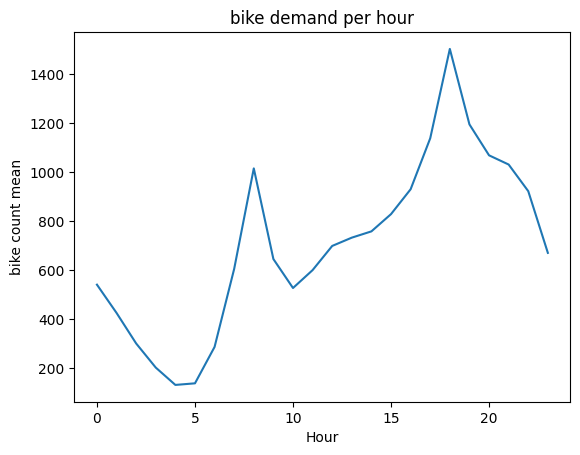

In [36]:
import matplotlib.pyplot as plt

plt.plot(df.groupby("Hour")["Rented Bike Count"].mean())
plt.xlabel("Hour")
plt.ylabel("bike count mean")
plt.title("bike demand per hour")
plt.show()

출퇴근 시간에 수요가 많은 것을 확인할 수 있다.

In [37]:
import torch

torch.__version__

'2.14.0+cu130'

In [68]:
from torch.utils.data import TensorDataset

df_torch_train = preprocessor.fit_transform(X_train)
df_torch_test = preprocessor.transform(X_test)

if hasattr(df_torch_train, "toarray"):
  print("df_torch to array")
  df_torch_train = df_torch_train.toarray()
  df_torch_test = df_torch_test.toarray()

X_train_tensor = torch.tensor(
  df_torch_train,
  dtype=torch.float32
)

X_test_tensor = torch.tensor(
  df_torch_test,
  dtype=torch.float32
)


train_dataset = TensorDataset(
  X_train_tensor, torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1, 1)
)

test_dataset = TensorDataset(
  X_test_tensor, torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)
)

In [69]:
len(train_dataset)

6132

In [70]:
from torch.utils.data import DataLoader

loader = {
  "train": DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    pin_memory=True
  ),
  "val": DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    pin_memory=True
  )
}

In [104]:
from torch import nn

class MyModel(nn.Module):
  def __init__(self, in_features, out_features):
    super().__init__()

    self.in_features=in_features
    self.out_features=out_features

    self.linear = nn.Sequential(
      nn.Linear(in_features, 64),
      nn.ReLU(),
      nn.Linear(64, 32),
      nn.ReLU(),

      nn.Linear(32, out_features)
    )

  def forward(self, x):

    return self.linear(x)


In [132]:
# 조금 더 복잡한 모델 사용해보기
from torch import nn

class MyModel(nn.Module):
  def __init__(self, in_features, out_features, dropout_p=0.5):
    super().__init__()

    self.in_features=in_features
    self.out_features=out_features

    self.linear = nn.Sequential(
      nn.Linear(in_features, 32),
      nn.BatchNorm1d(32),
      nn.ReLU(),
      nn.Dropout(p=dropout_p),

      nn.Linear(32, 64),
      nn.BatchNorm1d(64),
      nn.ReLU(),
      nn.Dropout(p=dropout_p),

      nn.Linear(64, 64),
      nn.BatchNorm1d(64),
      nn.ReLU(),
      nn.Dropout(p=dropout_p),

      nn.Linear(64, 32),
      nn.BatchNorm1d(32),
      nn.ReLU(),
      nn.Dropout(p=dropout_p),

      nn.Linear(32, out_features)
    )

  def forward(self, x):

    return self.linear(x)


In [136]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MyModel(X_test_tensor.shape[1], 1).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

criterion = torch.nn.MSELoss()

device

device(type='cuda')

In [ ]:
import copy

EPOCH = 1500

early_stop_counter = 0
PATIENCE = 5
best_val_loss = float("inf")
history = {
  "train_loss": [],
  "val_loss": []
}
best_model_epoch = 0

best_model_state_dict = None

for epoch in range(1, EPOCH+1):
  total_loss = 0

  for datas, labels in loader["train"]:

    datas = datas.to(device)
    labels = labels.to(device)
    
    optimizer.zero_grad()

    pred = model(datas)

    loss = criterion(pred, labels)

    loss.backward()

    optimizer.step()

    total_loss += loss.item() * labels.size(0)

  total_val_loss = 0
  with torch.inference_mode():
    model.eval()
    for datas, labels in loader["val"]:

      datas = datas.to(device)
      labels = labels.to(device)

      pred = model(datas)

      loss = criterion(pred, labels)

      total_val_loss += loss.item() * labels.size(0)
    model.train()

  total_loss /= len(train_dataset)
  total_val_loss /= len(test_dataset)

  history["train_loss"].append(total_loss)
  history["val_loss"].append(total_val_loss)

  if total_val_loss < best_val_loss:
    best_val_loss = total_val_loss
    best_model_epoch = epoch
    best_model_state_dict = copy.deepcopy(model.state_dict())
    early_stop_counter = 0
  else:
    early_stop_counter += 1

  if PATIENCE < early_stop_counter:
    print(" === early stop ===")
    break


  print(f"epoch: {epoch} | train MSE loss: {total_loss} | val MSE loss: {total_val_loss} | early-stop-counter: {early_stop_counter}")

# 상태 저장
torch.save({
  "best_model_epoch": best_model_epoch,
  "best_model_state_dict": best_model_state_dict,
  "latest_model_state_dict": model.state_dict(),
  "best_val_loss": best_val_loss,
}, "model-8-wd-1e-4-dropout-p-0.5.pth")

epoch: 1 | train MSE loss: 825197.7668378996 | val MSE loss: 1108706.104737443 | early-stop-counter: 0
epoch: 2 | train MSE loss: 820074.3473988911 | val MSE loss: 1103983.8970700153 | early-stop-counter: 0
epoch: 3 | train MSE loss: 811864.2228473581 | val MSE loss: 1097968.7032914765 | early-stop-counter: 0
epoch: 4 | train MSE loss: 801845.9203359426 | val MSE loss: 1091174.467085236 | early-stop-counter: 0
epoch: 5 | train MSE loss: 789256.7194634703 | val MSE loss: 1082282.1247146118 | early-stop-counter: 0
epoch: 6 | train MSE loss: 771277.7358121331 | val MSE loss: 1065251.3392313547 | early-stop-counter: 0
epoch: 7 | train MSE loss: 750603.4813682322 | val MSE loss: 1054497.4869197109 | early-stop-counter: 0
epoch: 8 | train MSE loss: 728575.3328033268 | val MSE loss: 1043614.4320776255 | early-stop-counter: 0
epoch: 9 | train MSE loss: 703886.4874021526 | val MSE loss: 1035975.0978405632 | early-stop-counter: 0
epoch: 10 | train MSE loss: 678017.0865337574 | val MSE loss: 1000

In [ ]:
from torch import nn

class MyModel_2(nn.Module):
  def __init__(self, in_features, out_features):
    super().__init__()

    self.in_features=in_features
    self.out_features=out_features

    self.linear = nn.Sequential(
      nn.Linear(in_features, 32),
      nn.ReLU(),
      nn.Linear(32, 16),
      nn.ReLU(),

      nn.Linear(16, out_features)
    )

  def forward(self, x):

    return self.linear(x)


In [97]:
torch.manual_seed(42)

model = MyModel(X_train_tensor.size(1), 1).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-2)

# checkpoint = torch.load("my-model-2.pth")

# if checkpoint is not None and checkpoint.get("best_model_state_dict") is not None:
#   model.load_state_dict(checkpoint["best_model_state_dict"])
  
# else:
  # optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)


EPOCH = 1500

early_stop_counter = 0
PATIENCE = 5
best_val_loss = float("inf")
history = {
  "train_loss": [],
  "val_loss": []
}
best_model_epoch = 0

best_model_state_dict = None

for epoch in range(1, EPOCH+1):
  total_loss = 0

  for datas, labels in loader["train"]:

    datas = datas.to(device)
    labels = labels.to(device)
    
    optimizer.zero_grad()

    pred = model(datas)

    loss = criterion(pred, labels)

    loss.backward()

    optimizer.step()

    total_loss += loss.item() * labels.size(0)

  total_val_loss = 0
  with torch.inference_mode():
    model.eval()
    for datas, labels in loader["val"]:

      datas = datas.to(device)
      labels = labels.to(device)

      pred = model(datas)

      loss = criterion(pred, labels)

      total_val_loss += loss.item() * labels.size(0)
    model.train()

  total_loss /= len(train_dataset)
  total_val_loss /= len(test_dataset)

  history["train_loss"].append(total_loss)
  history["val_loss"].append(total_val_loss)

  if total_val_loss < best_val_loss:
    best_val_loss = total_val_loss
    best_model_epoch = epoch
    best_model_state_dict = copy.deepcopy(model.state_dict())
    early_stop_counter = 0
  else:
    early_stop_counter += 1

  if PATIENCE <= early_stop_counter:
    print(" === early stop ===")
    break


  print(f"epoch: {epoch} | train MSE loss: {total_loss} | val MSE loss: {total_val_loss} | early-stop-counter: {early_stop_counter}")

# 상태 저장
torch.save({
  "best_model_epoch": best_model_epoch,
  "best_model_state_dict": best_model_state_dict,
  "latest_model_state_dict": model.state_dict(),
  "best_val_loss": best_val_loss,
}, "my-model-3-wd-1e-2.pth")


epoch: 1 | train MSE loss: 823937.4297129811 | val MSE loss: 1110685.5309170473 | early-stop-counter: 0
epoch: 2 | train MSE loss: 818300.8232224396 | val MSE loss: 1109177.6439307458 | early-stop-counter: 0
epoch: 3 | train MSE loss: 810497.711431833 | val MSE loss: 1104920.8279585235 | early-stop-counter: 0
epoch: 4 | train MSE loss: 798668.3067922374 | val MSE loss: 1087156.1217656012 | early-stop-counter: 0
epoch: 5 | train MSE loss: 781529.4415362035 | val MSE loss: 1085041.650922755 | early-stop-counter: 0
epoch: 6 | train MSE loss: 761504.4903783432 | val MSE loss: 1074521.8669615677 | early-stop-counter: 0
epoch: 7 | train MSE loss: 738995.4237606002 | val MSE loss: 1047251.3659151446 | early-stop-counter: 0
epoch: 8 | train MSE loss: 714389.5191617743 | val MSE loss: 1055413.1379375951 | early-stop-counter: 1
epoch: 9 | train MSE loss: 687693.3177185258 | val MSE loss: 1017633.4758371385 | early-stop-counter: 0
epoch: 10 | train MSE loss: 659067.6523157208 | val MSE loss: 9645

In [152]:
print("random_forest_mse\t\t\t\t :", random_forest_mse)
print("ridge_mse\t\t\t\t\t :", ridge_mse)
print()
print("model-1-wd-1e-2.pth \t\t  - best_val_loss:", torch.load("model-1-wd-1e-2.pth")["best_val_loss"])
print("model-2-wd-1e-4.pth \t\t  - best_val_loss:", torch.load("model-2-wd-1e-4.pth")["best_val_loss"])
print("model-3-wd-1e-2.pth \t\t  - best_val_loss:", torch.load("model-3-wd-1e-2.pth")["best_val_loss"])
print("model-4-wd-1e-4.pth \t\t  - best_val_loss:", torch.load("model-4-wd-1e-4.pth")["best_val_loss"])
print("model-5-wd-1e-8.pth \t\t  - best_val_loss:", torch.load("model-5-wd-1e-8.pth")["best_val_loss"])
print("model-6-wd-1e-2-dropout-p-0.2.pth - best_val_loss:", torch.load("model-6-wd-1e-2-dropout-p-0.2.pth")["best_val_loss"])
print("model-7-wd-1e-2-dropout-p-0.5.pth - best_val_loss:", torch.load("model-7-wd-1e-2-dropout-p-0.5.pth")["best_val_loss"])
print("model-8-wd-1e-4-dropout-p-0.5.pth - best_val_loss:", torch.load("model-8-wd-1e-4-dropout-p-0.5.pth")["best_val_loss"])

random_forest_mse				 : 139833.32049421614
ridge_mse					 : 365030.7891070011

model-1-wd-1e-2.pth 		  - best_val_loss: 447620.28077435313
model-2-wd-1e-4.pth 		  - best_val_loss: 220683.6885939878
model-3-wd-1e-2.pth 		  - best_val_loss: 177962.1665655917
model-4-wd-1e-4.pth 		  - best_val_loss: 185796.78368174468
model-5-wd-1e-8.pth 		  - best_val_loss: 236831.67706549657
model-6-wd-1e-2-dropout-p-0.2.pth - best_val_loss: 190705.99194373097
model-7-wd-1e-2-dropout-p-0.5.pth - best_val_loss: 249743.5901856212
model-8-wd-1e-4-dropout-p-0.5.pth - best_val_loss: 329310.09405917046


In [103]:
print(torch.load("model.pth")["best_val_loss"])
print(torch.load("my-model-2.pth")["best_val_loss"])
print(torch.load("my-model-2-weight-decay-0.0001.pth")["best_val_loss"])
print(torch.load("my-model-2-weight-decay-1e-8.pth")["best_val_loss"])
print(torch.load("my-model-3-wd-1e-2.pth")["best_val_loss"])
print(torch.load("my-model-3-wd-1e-8.pth")["best_val_loss"])
print(torch.load("my-model-3-wd-1e-2-dropout-0.2.pth")["best_val_loss"])
print(torch.load("my-model-3-wd-1e-2-dropout-0.5.pth")["best_val_loss"])



456879.8928129756
454911.70800038055
454830.9625190259
454816.12549942924
240370.1747586092
259697.81936640863
220676.00767277874
235500.77413313356


In [57]:
for n, p in model.named_parameters():
  print(n, p.shape)

linear.0.weight torch.Size([64, 6153])
linear.0.bias torch.Size([64])
linear.2.weight torch.Size([32, 64])
linear.2.bias torch.Size([32])
linear.4.weight torch.Size([1, 32])
linear.4.bias torch.Size([1])


In [ ]:
df_datetime_cycle.head()

,Rented Bike Count,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos
0,254,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,-0.5,0.866025,-0.433884,-0.900969,0.000000,1.000000
1,204,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,-0.5,0.866025,-0.433884,-0.900969,0.258819,0.965926
2,173,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,-0.5,0.866025,-0.433884,-0.900969,0.500000,0.866025
3,107,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,-0.5,0.866025,-0.433884,-0.900969,0.707107,0.707107
4,78,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,-0.5,0.866025,-0.433884,-0.900969,0.866025,0.500000


In [53]:
tmp_df = preprocessor.transform(
  df_datetime_cycle.drop(columns=target_features)
)

if hasattr(tmp_df, "toarray"):
  tmp_df = tmp_df.toarray()

X = torch.tensor(
  tmp_df,
  dtype=torch.float32
).to(device)

model.eval()

with torch.inference_mode():
  # 결과를 df에 넣을 수 있는 형태로 변환
  pred = model(X[-16:]).squeeze(1).cpu()

result = pd.concat(
  [
    df_datetime_cycle["Rented Bike Count"][-16:].reset_index(drop=True),
    pd.Series(pred.tolist(), name="pred")
  ],
  axis=1
)
result["diff"] = (
  result["Rented Bike Count"] - result["pred"]
).abs()

result

,Rented Bike Count,pred,diff
0,1527,274.174011,1252.825989
1,809,280.741028,528.258972
2,554,300.515015,253.484985
3,642,342.688904,299.311096
4,720,347.693604,372.306396
5,740,368.201538,371.798462
6,761,375.066711,385.933289
7,768,426.137299,341.862701
8,837,486.449860,350.550140
9,1047,552.024963,494.975037


In [100]:
# 조금 더 복잡한 모델 사용해보기
from torch import nn

class MyModel(nn.Module):
  def __init__(self, in_features, out_features, dropout_p=0.2):
    super().__init__()

    self.in_features=in_features
    self.out_features=out_features

    self.linear = nn.Sequential(
      nn.Linear(in_features, 32),
      nn.BatchNorm1d(32),
      nn.ReLU(),
      nn.Dropout(p=dropout_p),

      nn.Linear(32, 64),
      nn.BatchNorm1d(64),
      nn.ReLU(),
      nn.Dropout(p=dropout_p),

      nn.Linear(64, 64),
      nn.BatchNorm1d(64),
      nn.ReLU(),
      nn.Dropout(p=dropout_p),

      nn.Linear(64, 32),
      nn.BatchNorm1d(32),
      nn.ReLU(),
      nn.Dropout(p=dropout_p),

      nn.Linear(32, out_features)
    )

  def forward(self, x):

    return self.linear(x)


In [ ]:
from torch import nn

class MyModel_3(nn.Module):
  def __init__(self, in_features, out_features):
    super().__init__()

    self.in_features=in_features
    self.out_features=out_features

    self.linear = nn.Sequential(
      nn.Linear(in_features, 32),
      nn.ReLU(),
      nn.Linear(32, 16),
      nn.ReLU(),

      nn.Linear(16, out_features)
    )

  def forward(self, x):

    return self.linear(x)


In [102]:
model = MyModel(X_train_tensor.size(1), 1, dropout_p=0.5).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)

EPOCH = 1500

early_stop_counter = 0
PATIENCE = 5
best_val_loss = float("inf")
history = {
  "train_loss": [],
  "val_loss": []
}
best_model_epoch = 0

best_model_state_dict = None

for epoch in range(1, EPOCH+1):
  total_loss = 0

  for datas, labels in loader["train"]:

    datas = datas.to(device)
    labels = labels.to(device)
    
    optimizer.zero_grad()

    pred = model(datas)

    loss = criterion(pred, labels)

    loss.backward()

    optimizer.step()

    total_loss += loss.item() * labels.size(0)

  total_val_loss = 0
  with torch.inference_mode():
    model.eval()
    for datas, labels in loader["val"]:

      datas = datas.to(device)
      labels = labels.to(device)

      pred = model(datas)

      loss = criterion(pred, labels)

      total_val_loss += loss.item() * labels.size(0)
    model.train()

  total_loss /= len(train_dataset)
  total_val_loss /= len(test_dataset)

  history["train_loss"].append(total_loss)
  history["val_loss"].append(total_val_loss)

  if total_val_loss < best_val_loss:
    best_val_loss = total_val_loss
    best_model_epoch = epoch
    best_model_state_dict = copy.deepcopy(model.state_dict())
    early_stop_counter = 0
  else:
    early_stop_counter += 1

  if PATIENCE < early_stop_counter:
    print(" === early stop ===")
    break


  print(f"epoch: {epoch} | train MSE loss: {total_loss} | val MSE loss: {total_val_loss} | early-stop-counter: {early_stop_counter}")

# 상태 저장
torch.save({
  "best_model_epoch": best_model_epoch,
  "best_model_state_dict": best_model_state_dict,
  "latest_model_state_dict": model.state_dict(),
  "best_val_loss": best_val_loss,
}, "my-model-3-wd-1e-2-dropout-0.5.pth")


epoch: 1 | train MSE loss: 824701.7400521853 | val MSE loss: 1108724.8999714612 | early-stop-counter: 0
epoch: 2 | train MSE loss: 818431.8325994782 | val MSE loss: 1104244.3115011416 | early-stop-counter: 0
epoch: 3 | train MSE loss: 809467.4998776908 | val MSE loss: 1099367.6627187976 | early-stop-counter: 0
epoch: 4 | train MSE loss: 797634.6715590346 | val MSE loss: 1091822.530631659 | early-stop-counter: 0
epoch: 5 | train MSE loss: 782509.9598418134 | val MSE loss: 1079973.2400589802 | early-stop-counter: 0
epoch: 6 | train MSE loss: 764776.5909165036 | val MSE loss: 1071306.6345605024 | early-stop-counter: 0
epoch: 7 | train MSE loss: 744233.9889106328 | val MSE loss: 1050141.5572678843 | early-stop-counter: 0
epoch: 8 | train MSE loss: 720773.416014351 | val MSE loss: 1026253.5604071537 | early-stop-counter: 0
epoch: 9 | train MSE loss: 697370.1934116113 | val MSE loss: 1011329.6532534247 | early-stop-counter: 0
epoch: 10 | train MSE loss: 673062.7803530659 | val MSE loss: 9811